In [1]:
!pip install folium

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

LOADING DATASET

In [3]:
df = pd.read_csv("/content/Dataset  (11).csv")

CHECKING DATASET

In [4]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


CHECKING LATITUDE AND LONGITUDE

In [5]:
df[['Restaurant Name','City','Latitude','Longitude']]

,Restaurant Name,City,Latitude,Longitude
0,Le Petit Souffle,Makati City,14.565443,121.027535
1,Izakaya Kikufuji,Makati City,14.553708,121.014101
2,Heat - Edsa Shangri-La,Mandaluyong City,14.581404,121.056831
3,Ooma,Mandaluyong City,14.585318,121.056475
4,Sambo Kojin,Mandaluyong City,14.584450,121.057508
...,...,...,...,...
9546,Naml۱ Gurme,��stanbul,41.022793,28.977392
9547,Ceviz A��ac۱,��stanbul,41.009847,29.041297
9548,Huqqa,��stanbul,41.055817,29.034640
9549,A���k Kahve,��stanbul,41.057979,29.036019


In [9]:
restaurant_map = folium.Map(
    location=[df['Latitude'].mean(),
              df['Longitude'].mean()],
    zoom_start=5
)
restaurant_map

In [12]:
sample_df = df.sample(500, random_state=42)

In [14]:
for _, row in sample_df.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'],
                  row['Longitude']],
        radius=2,
        popup=row['Restaurant Name'],
        fill=True
    ).add_to(restaurant_map)

In [15]:
restaurant_map

TOP CITIES ANALYSIS

In [16]:
top_cities = df['City'].value_counts().head(10)

print(top_cities)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64


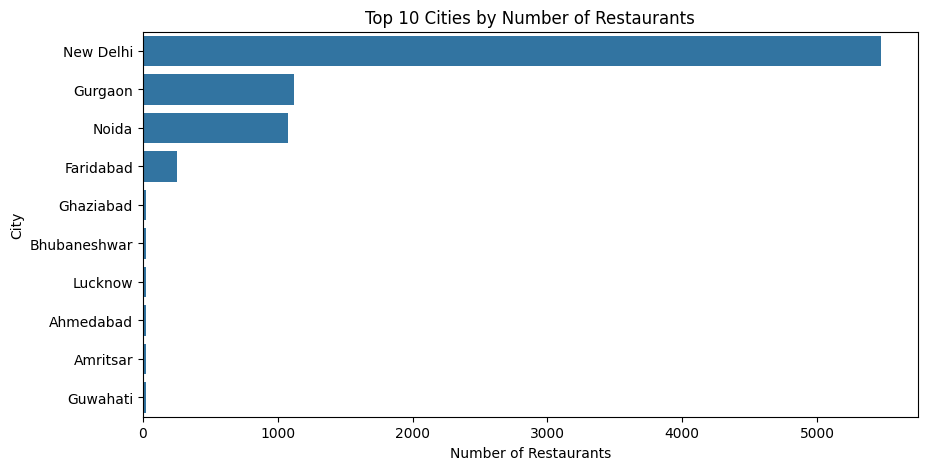

In [19]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")

plt.show()

COUNTRIES DISTRIBUTION

In [20]:
country_counts = df['Country Code'].value_counts()

print(country_counts)

Country Code
1      8652
216     434
215      80
30       60
189      60
214      60
148      40
208      34
14       24
162      22
94       21
166      20
184      20
191      20
37        4
Name: count, dtype: int64


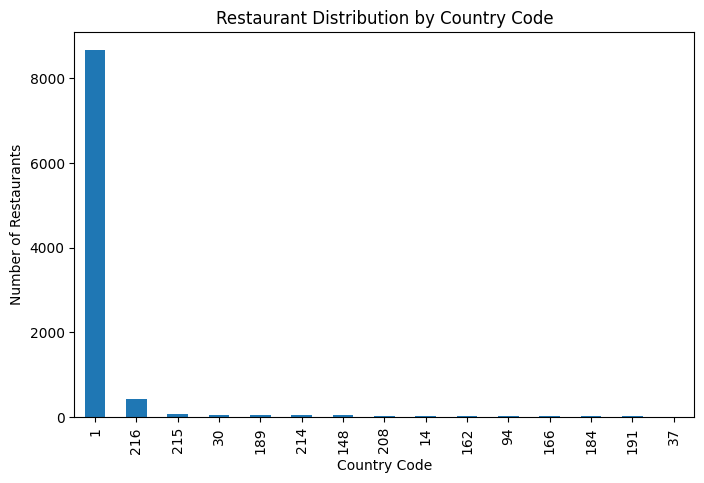

In [21]:
plt.figure(figsize=(8,5))

country_counts.plot(kind='bar')

plt.title("Restaurant Distribution by Country Code")
plt.xlabel("Country Code")
plt.ylabel("Number of Restaurants")

plt.show()

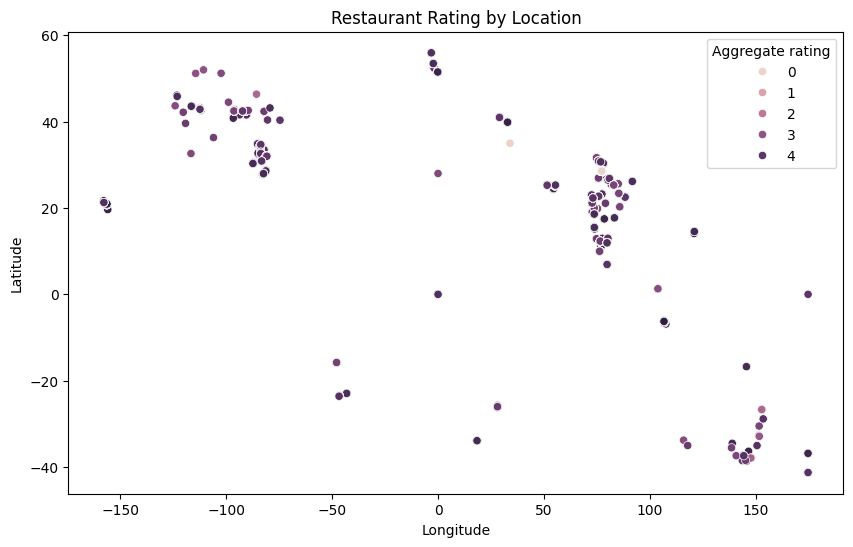

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Longitude',
    y='Latitude',
    hue='Aggregate rating'
)

plt.title("Restaurant Rating by Location")

plt.show()

KEY FINDINGS

In [23]:
print("Top 5 Cities:")
print(df['City'].value_counts().head())

print("\nAverage Rating:")
print(df['Aggregate rating'].mean())

Top 5 Cities:
City
New Delhi    5473
Gurgaon      1118
Noida        1080
Faridabad     251
Ghaziabad      25
Name: count, dtype: int64

Average Rating:
2.66637001361114
